# EDA — Previsão de Preços de Ações (AAPL)

**Datathon FIAP — Fase 05 | Grupo 29**

## Contexto do Problema

Instituições financeiras precisam antecipar movimentos de preço de ativos para decisões de alocação, gestão de risco e execução de ordens. O problema central é: **dado o histórico de preços e indicadores técnicos dos últimos 60 pregões, qual será o preço da ação AAPL daqui a 5 dias úteis?**

Este notebook documenta a análise exploratória dos dados históricos (2018–2026) com foco em:
1. Caracterização da série temporal e distribuição dos retornos
2. Análise de volatilidade e regimes de mercado
3. Comportamento dos indicadores técnicos utilizados como features
4. Análise da variável-alvo (delta de 5 dias)
5. Correlações e multicolinearidade entre features
6. Validação da estratégia de split temporal

**Relevância para o negócio**: Cada insight abaixo informou decisões de feature engineering e arquitetura do modelo LSTM.

In [1]:
import warnings

warnings.filterwarnings('ignore')

import sys

sys.path.insert(0, '..')

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src.features.feature_engineering import FEATURE_COLS, build_features, temporal_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 1. Carregamento e Visão Geral dos Dados

In [2]:
import yfinance as yf

df_raw = yf.download('AAPL', start='2018-01-01', end='2026-01-01')
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw.dropna()

print(f'Período: {df_raw.index[0].date()} -> {df_raw.index[-1].date()}')
print(f'Pregões: {len(df_raw):,}')
print(f'Anos cobertos: {len(df_raw) / 252:.1f}')
print()
df_raw.describe().round(2)

[*********************100%***********************]  1 of 1 completed

Período: 2018-01-02 -> 2025-12-31
Pregões: 2,011
Anos cobertos: 8.0



Price,Close,High,Low,Open,Volume
count,2011.00,2011.00,2011.00,2011.00,2.011000e+03
mean,135.39,136.76,133.89,135.26,9.442735e+07
std,66.75,67.33,66.10,66.69,5.447156e+07
min,33.77,34.61,33.72,34.19,1.791060e+07
25%,64.33,64.88,63.53,64.17,5.563230e+07
50%,142.81,144.35,141.12,142.66,8.096270e+07
75%,182.79,184.55,180.93,182.48,1.151288e+08
max,285.92,288.35,283.04,285.93,4.265100e+08


In [3]:
print('Valores nulos por coluna:')
print(df_raw.isnull().sum())
print(f'Total de registros validos: {len(df_raw)} (sem nulos)')

Valores nulos por coluna:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Total de registros validos: 2011 (sem nulos)


## 2. Série Temporal de Preços e Regimes de Mercado

**Insight de negócio**: A série AAPL (2018–2026) cobre múltiplos regimes de mercado, incluindo o crash de COVID-19 (mar/2020), rally de recuperação (2020–2021), correção por alta de juros (2022) e recuperação com IA (2023–2024). Um modelo robusto deve performar em todos esses regimes.

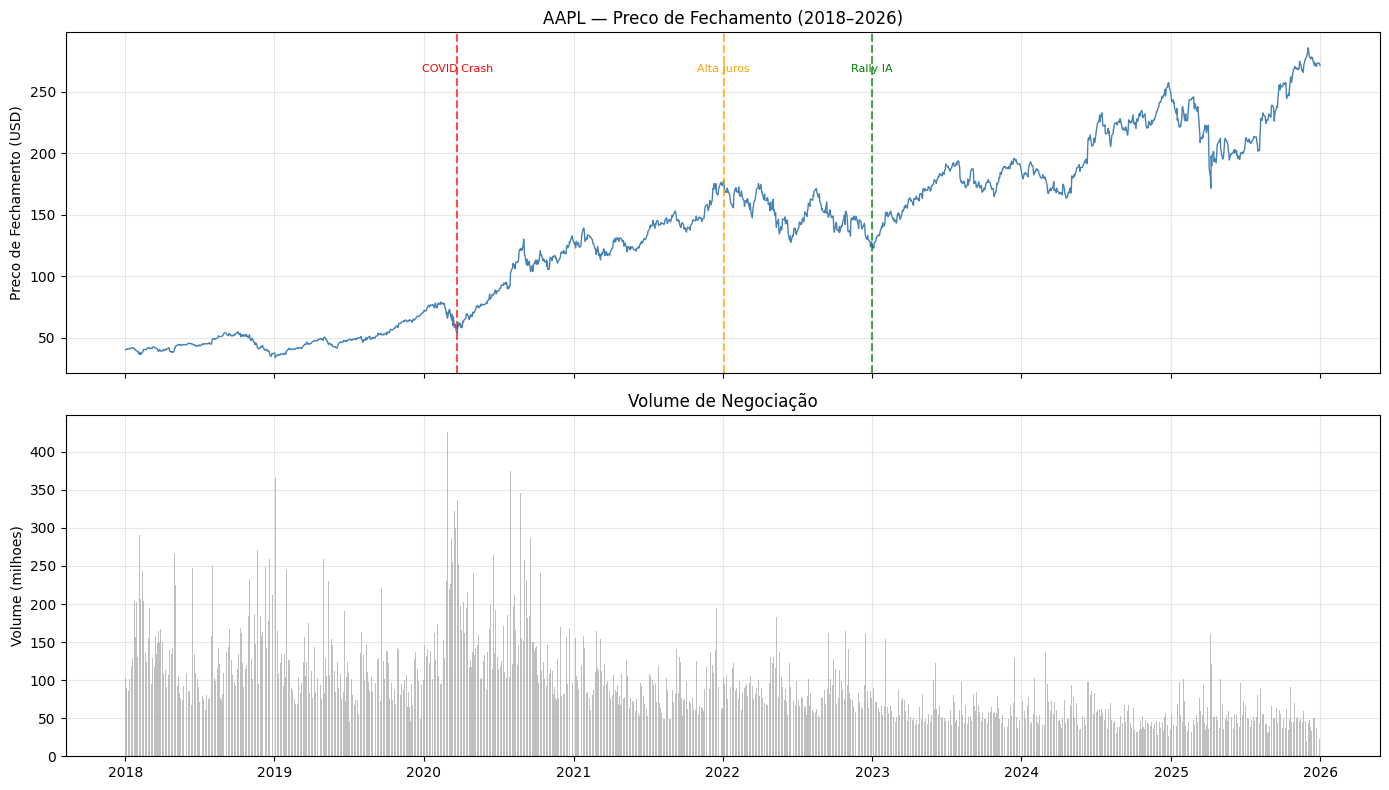

Retorno total no período: 573.9%
Retorno anualizado: 26.9%


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Preco de Fechamento (USD)')
axes[0].set_title('AAPL — Preco de Fechamento (2018–2026)')

events = {
    '2020-03-23': ('COVID Crash', 'red'),
    '2022-01-03': ('Alta Juros', 'orange'),
    '2023-01-01': ('Rally IA', 'green'),
}
for date_str, (label, color) in events.items():
    date = pd.Timestamp(date_str)
    axes[0].axvline(date, color=color, linestyle='--', alpha=0.7, linewidth=1.5)
    axes[0].text(date, df_raw['Close'].max() * 0.93, label, color=color, fontsize=8, ha='center')

axes[1].bar(df_raw.index, df_raw['Volume'] / 1e6, color='gray', alpha=0.5, width=1)
axes[1].set_ylabel('Volume (milhoes)')
axes[1].set_title('Volume de Negociação')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../data/processed/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()

ret_total = (df_raw['Close'].iloc[-1] / df_raw['Close'].iloc[0] - 1) * 100
print(f'Retorno total no período: {ret_total:.1f}%')
print(f'Retorno anualizado: {((1 + ret_total / 100) ** (1 / 8) - 1) * 100:.1f}%')

## 3. Distribuição dos Retornos Diários

**Insight de negócio**: Retornos financeiros apresentam **caudas pesadas** (leptocurtose) — eventos extremos ocorrem com frequência muito maior do que uma distribuição normal preveria. Isso justifica o uso do **Huber Loss** no treinamento (robusto a outliers) e do **RobustScaler** no pré-processamento.

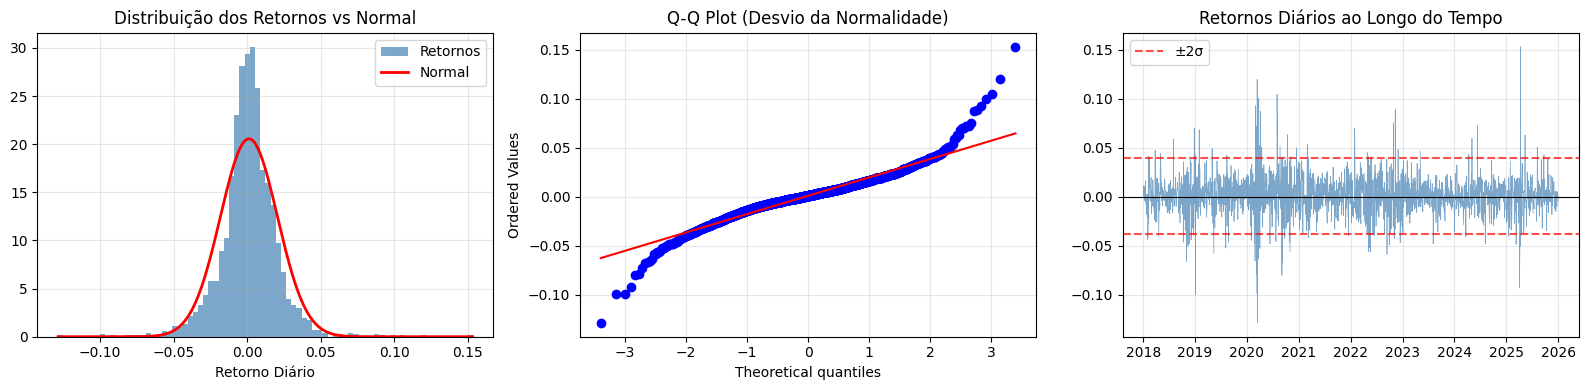

Média diária    : 0.114%
Desvio padrão   : 1.940%
Assimetria      : 0.155 (negativa = cauda esquerda maior)
Curtose excess. : 6.431 (>0 = caudas pesadas)
Jarque-Bera p   : 0.00e+00 (p<0.05 = rejeita normalidade)

-> DECISÃO: Huber Loss e RobustScaler são escolhas justificadas pelos dados.


In [5]:
returns = df_raw['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(returns, bins=80, density=True, alpha=0.7, color='steelblue', label='Retornos')
x = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', linewidth=2, label='Normal')
axes[0].set_title('Distribuição dos Retornos vs Normal')
axes[0].set_xlabel('Retorno Diário')
axes[0].legend()

stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Desvio da Normalidade)')

axes[2].plot(returns.index, returns, color='steelblue', linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(returns.mean() + 2 * returns.std(), color='red', linestyle='--', alpha=0.7, label='±2σ')
axes[2].axhline(returns.mean() - 2 * returns.std(), color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Retornos Diários ao Longo do Tempo')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_returns_dist.png', dpi=150, bbox_inches='tight')
plt.show()

kurt = stats.kurtosis(returns)
skew = stats.skew(returns)
_, jb_p = stats.jarque_bera(returns)
print(f'Média diária    : {returns.mean() * 100:.3f}%')
print(f'Desvio padrão   : {returns.std() * 100:.3f}%')
print(f'Assimetria      : {skew:.3f} (negativa = cauda esquerda maior)')
print(f'Curtose excess. : {kurt:.3f} (>0 = caudas pesadas)')
print(f'Jarque-Bera p   : {jb_p:.2e} (p<0.05 = rejeita normalidade)')
print()
print('-> DECISÃO: Huber Loss e RobustScaler são escolhas justificadas pelos dados.')

## 4. Volatilidade e Clustering

**Insight de negócio**: A volatilidade apresenta **clustering** — períodos de alta volatilidade tendem a ser seguidos por mais alta volatilidade (efeito ARCH). Features `vol_7` e `vol_21` capturam esse regime de incerteza e são informativas para o modelo.

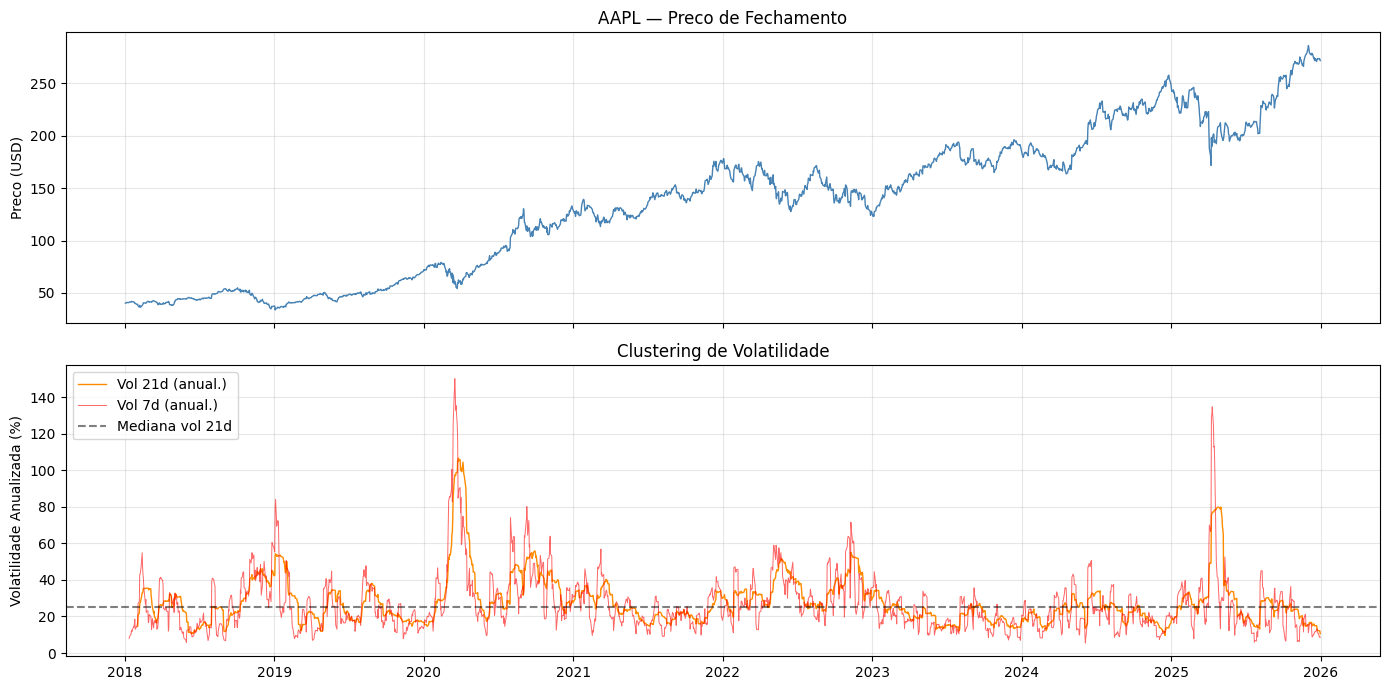

Volatilidade mediana (21d anual.): 25.1%
Volatilidade máxima  (21d anual.): 106.7%
Pregões com vol > 40% anual.: 254 (12.6% do período)
-> DECISÃO: vol_7 e vol_21 incluídas como features — capturam regime de incerteza.


In [6]:
vol_21 = returns.rolling(21).std() * np.sqrt(252)
vol_7 = returns.rolling(7).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Preco (USD)')
axes[0].set_title('AAPL — Preco de Fechamento')

axes[1].plot(vol_21.index, vol_21 * 100, color='darkorange', linewidth=1, label='Vol 21d (anual.)')
axes[1].plot(vol_7.index, vol_7 * 100, color='red', linewidth=0.7, alpha=0.6, label='Vol 7d (anual.)')
axes[1].axhline(vol_21.median() * 100, color='black', linestyle='--', alpha=0.5, label='Mediana vol 21d')
axes[1].set_ylabel('Volatilidade Anualizada (%)')
axes[1].set_title('Clustering de Volatilidade')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Volatilidade mediana (21d anual.): {vol_21.median() * 100:.1f}%')
print(f'Volatilidade máxima  (21d anual.): {vol_21.max() * 100:.1f}%')
print(f'Pregões com vol > 40% anual.: {(vol_21 > 0.40).sum()} ({(vol_21 > 0.40).mean() * 100:.1f}% do período)')
print('-> DECISÃO: vol_7 e vol_21 incluídas como features — capturam regime de incerteza.')

## 5. Análise dos Indicadores Técnicos

**Insight de negócio**: Os 16 indicadores técnicos cobrem 4 famílias complementares — tendência (SMAs, EMAs), momentum (MACD, RSI), volatilidade (vol_7, vol_21) e preço bruto (OHLCV). A redundância parcial é gerenciada pelo LSTM, que aprende quais sinais são relevantes em cada regime.

In [7]:
feats = build_features(df_raw, horizon=5)
print(f'Shape apos feature engineering: {feats.shape}')
print(f'Registros perdidos (NaN drop): {len(df_raw) - len(feats)} (lookback de indicadores)')
print(f'Features: {FEATURE_COLS}')

Shape apos feature engineering: (1985, 19)
Registros perdidos (NaN drop): 26 (lookback de indicadores)
Features: ['close', 'high', 'low', 'open', 'volume', 'ret_1', 'log_ret_1', 'sma_7', 'sma_21', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'vol_7', 'vol_21']


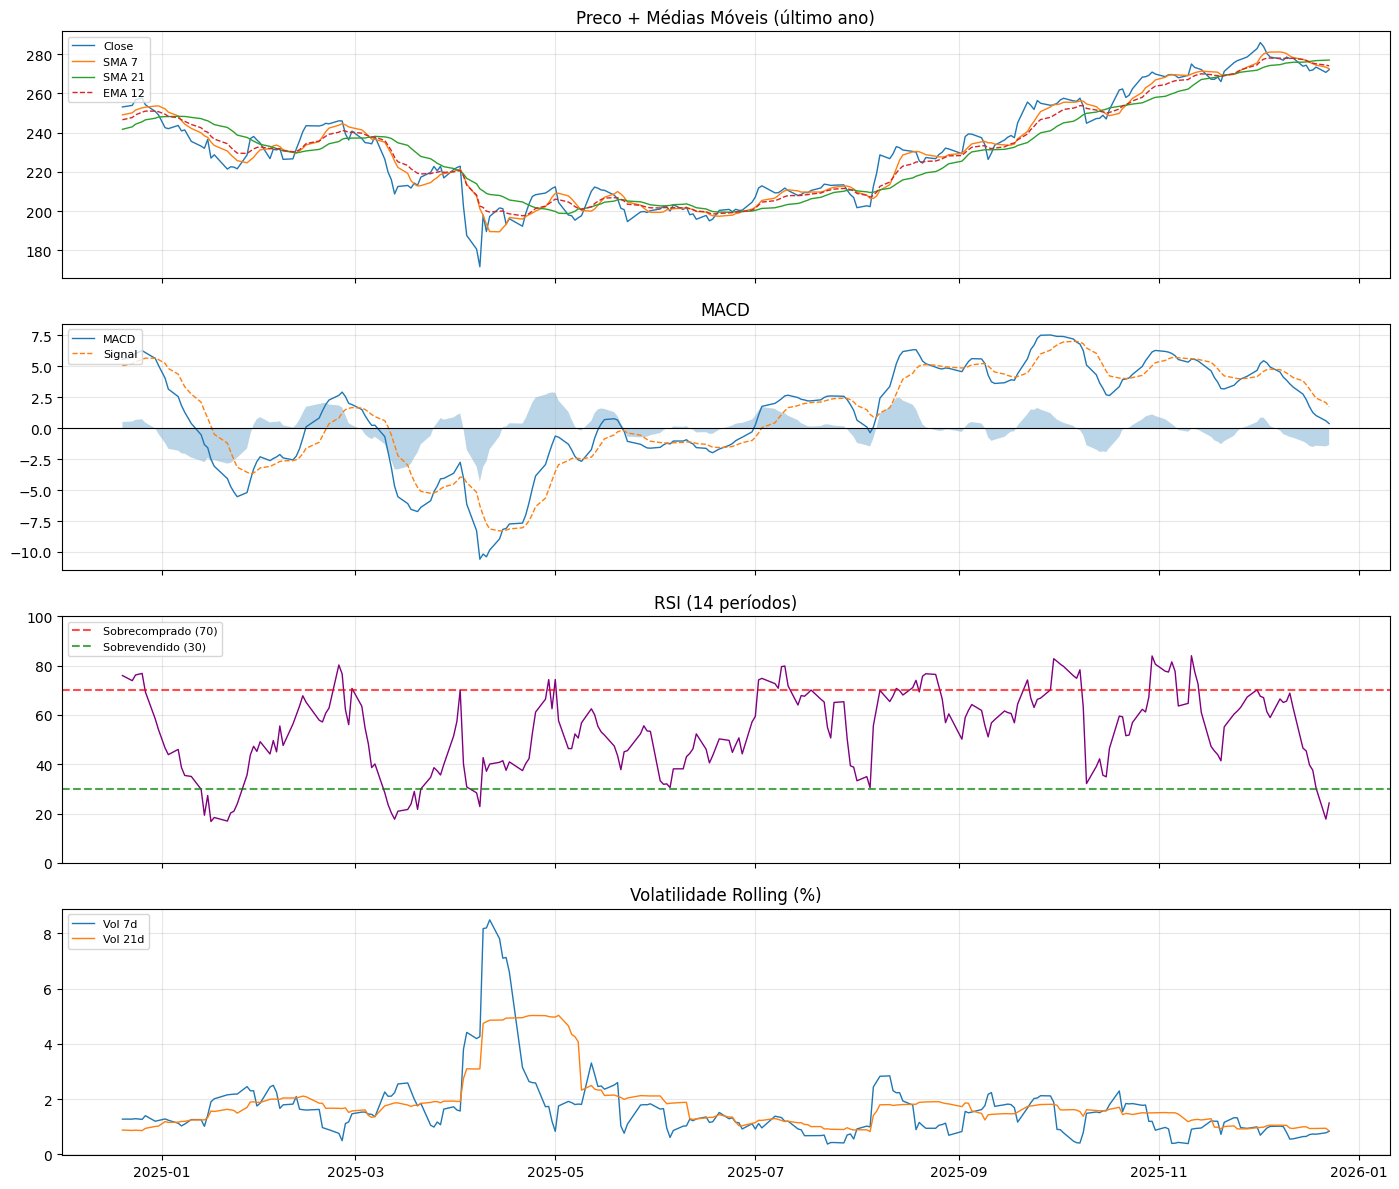

In [8]:
sample = feats.tail(252)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(sample.index, sample['close'], label='Close', linewidth=1)
axes[0].plot(sample.index, sample['sma_7'], label='SMA 7', linewidth=1)
axes[0].plot(sample.index, sample['sma_21'], label='SMA 21', linewidth=1)
axes[0].plot(sample.index, sample['ema_12'], label='EMA 12', linewidth=1, linestyle='--')
axes[0].set_title('Preco + Médias Móveis (último ano)')
axes[0].legend(loc='upper left', fontsize=8)

axes[1].plot(sample.index, sample['macd'], label='MACD', linewidth=1)
axes[1].plot(sample.index, sample['macd_signal'], label='Signal', linewidth=1, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].fill_between(sample.index, sample['macd'] - sample['macd_signal'], alpha=0.3)
axes[1].set_title('MACD')
axes[1].legend(loc='upper left', fontsize=8)

axes[2].plot(sample.index, sample['rsi_14'], color='purple', linewidth=1)
axes[2].axhline(70, color='red', linestyle='--', alpha=0.7, label='Sobrecomprado (70)')
axes[2].axhline(30, color='green', linestyle='--', alpha=0.7, label='Sobrevendido (30)')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14 períodos)')
axes[2].legend(loc='upper left', fontsize=8)

axes[3].plot(sample.index, sample['vol_7'] * 100, label='Vol 7d', linewidth=1)
axes[3].plot(sample.index, sample['vol_21'] * 100, label='Vol 21d', linewidth=1)
axes[3].set_title('Volatilidade Rolling (%)')
axes[3].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/eda_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análise da Variável-Alvo

**Insight de negócio**: O target é `y_delta_h = close(t+5) - close(t)` — o delta de preço em dólares para 5 dias à frente. Modelar o delta ao invés do preço absoluto é intencional:
- **Estacionaridade**: O delta é mais estacionário que o preço bruto → melhora convergência do LSTM
- **Interpretabilidade**: Um delta de +$5 é diretamente acionável pela mesa de operações
- **Simetria**: Deltas positivos e negativos têm frequência similar → sem viés de direção

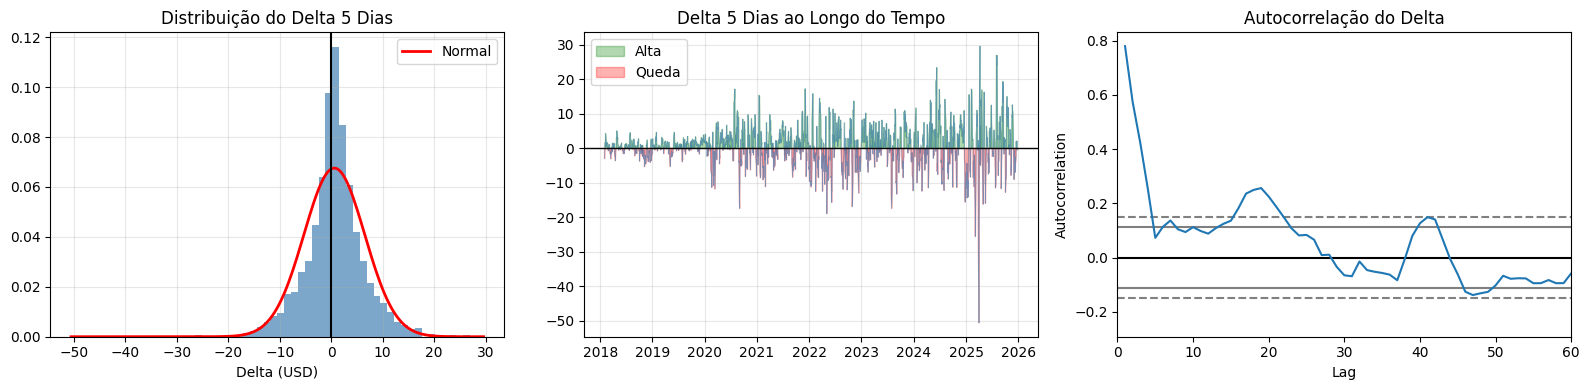

Média do delta 5d  : $0.59
Mediana do delta 5d: $0.60
Std do delta 5d    : $5.90
Deltas positivos   : 58.4% (leve viés de alta)
Percentil 5%  : $-8.91
Percentil 95% : $10.09

-> DECISÃO: Target como delta é mais estacionário e facilita aprendizado do LSTM.


In [9]:
target = feats['y_delta_h']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(target, bins=60, density=True, alpha=0.7, color='steelblue')
x = np.linspace(target.min(), target.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, target.mean(), target.std()), 'r-', linewidth=2, label='Normal')
axes[0].axvline(0, color='black', linewidth=1.5)
axes[0].set_title('Distribuição do Delta 5 Dias')
axes[0].set_xlabel('Delta (USD)')
axes[0].legend()

axes[1].plot(feats.index, target, linewidth=0.5, alpha=0.7, color='steelblue')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].fill_between(feats.index, target, alpha=0.3, where=(target > 0), color='green', label='Alta')
axes[1].fill_between(feats.index, target, alpha=0.3, where=(target < 0), color='red', label='Queda')
axes[1].set_title('Delta 5 Dias ao Longo do Tempo')
axes[1].legend()

from pandas.plotting import autocorrelation_plot

autocorrelation_plot(target.iloc[:300], ax=axes[2])
axes[2].set_title('Autocorrelação do Delta')
axes[2].set_xlim(0, 60)

plt.tight_layout()
plt.savefig('../data/processed/eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

positive_pct = (target > 0).mean() * 100
print(f'Média do delta 5d  : ${target.mean():.2f}')
print(f'Mediana do delta 5d: ${target.median():.2f}')
print(f'Std do delta 5d    : ${target.std():.2f}')
print(f'Deltas positivos   : {positive_pct:.1f}% (leve viés de alta)')
print(f'Percentil 5%  : ${target.quantile(0.05):.2f}')
print(f'Percentil 95% : ${target.quantile(0.95):.2f}')
print()
print('-> DECISÃO: Target como delta é mais estacionário e facilita aprendizado do LSTM.')

## 7. Correlação entre Features e com o Target

**Insight de negócio**: O mapa de correlações informa quais features adicionam sinal único ao modelo. SMAs e EMAs são altamente correlacionadas entre si, mas cada uma captura uma escala temporal diferente — justificando mantê-las todas.

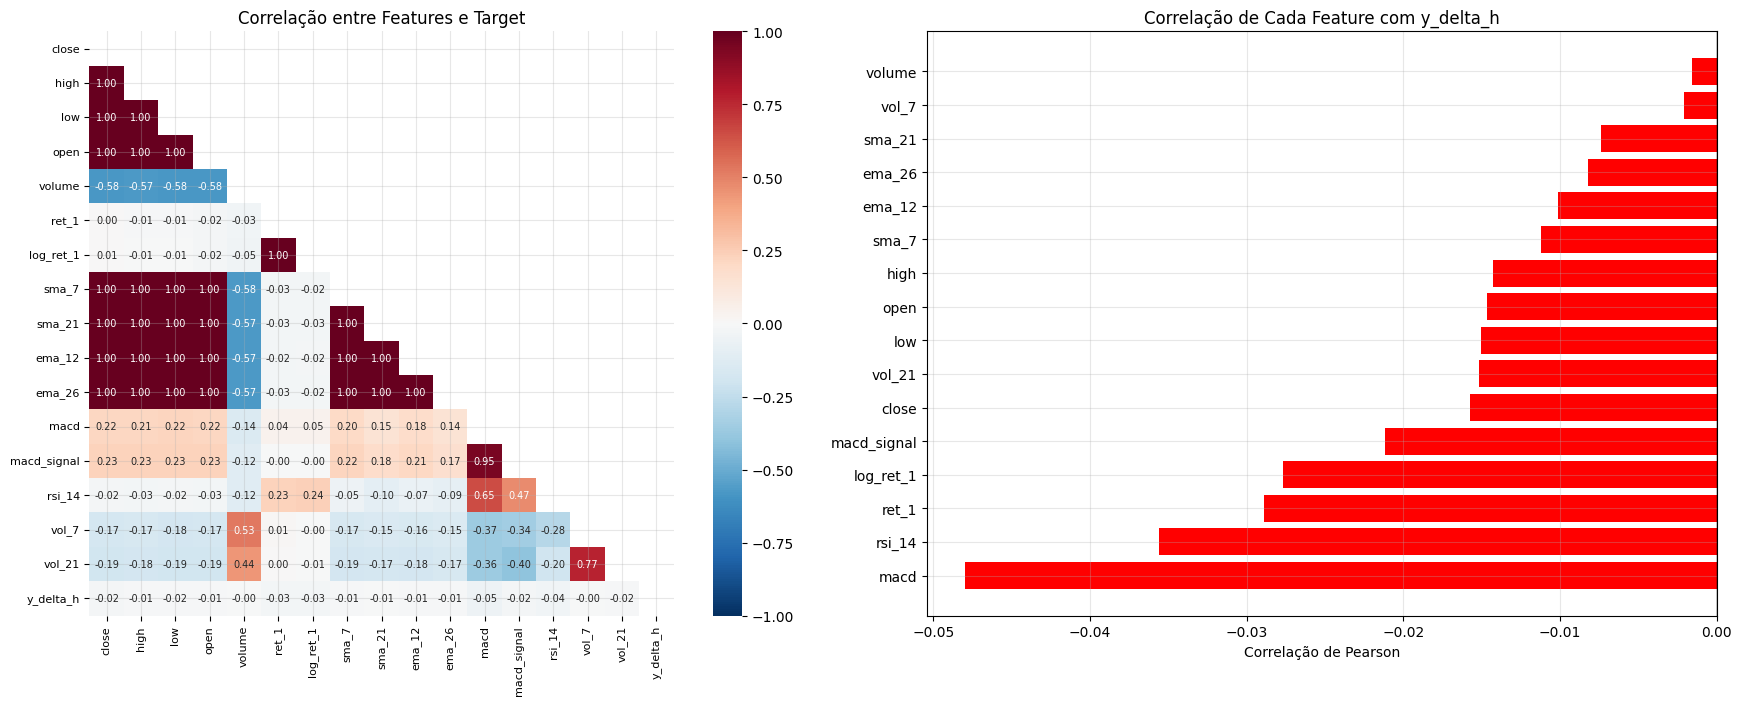

Features mais correlacionadas com y_delta_h:
macd           0.048
rsi_14         0.036
ret_1          0.029
log_ret_1      0.028
macd_signal    0.021
close          0.016
vol_21         0.015
low            0.015
Name: y_delta_h, dtype: float64


In [10]:
corr_data = feats[FEATURE_COLS + ['y_delta_h']].copy()
corr_matrix = corr_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, square=True
)
axes[0].set_title('Correlação entre Features e Target')
axes[0].tick_params(labelsize=8)

target_corr = corr_matrix['y_delta_h'].drop('y_delta_h').sort_values()
colors = ['red' if v < 0 else 'steelblue' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Correlação de Cada Feature com y_delta_h')
axes[1].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.savefig('../data/processed/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features mais correlacionadas com y_delta_h:')
print(target_corr.abs().sort_values(ascending=False).head(8).round(3))

## 8. Validação do Split Temporal

**Insight de negócio**: Em séries temporais financeiras, o `train_test_split` aleatório causa **data leakage** — o modelo veria dados futuros durante o treino. O split temporal estrito garante que o modelo sempre prediz o futuro, simulando o ambiente de produção.

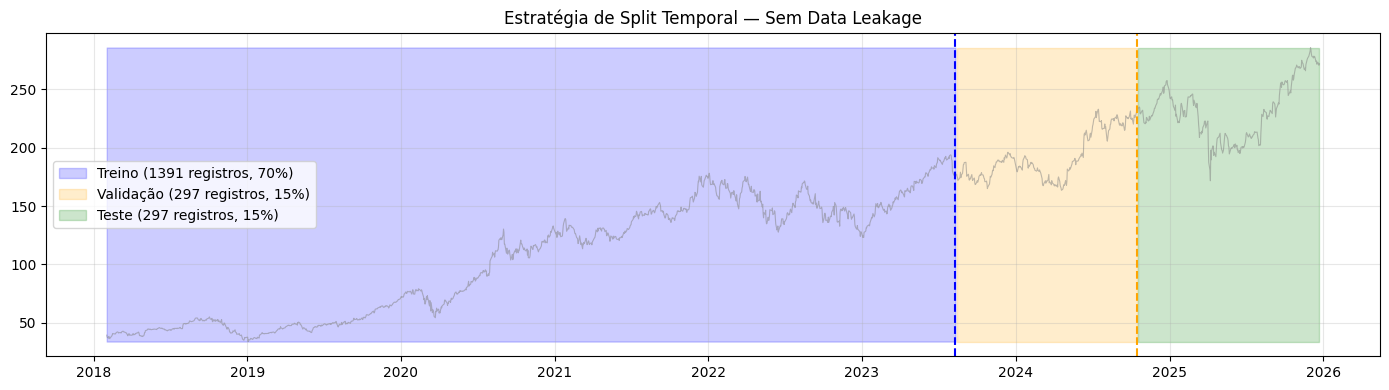

Treino    : 2018-02-01 → 2023-08-11 (1391 registros)
Validação : → 2024-10-16 (297 registros)
Teste     : → 2025-12-23 (297 registros)

-> DECISÃO: RobustScaler fitado APENAS nos dados de treino para evitar leakage.


In [11]:
train_end, val_end = temporal_split(pd.DatetimeIndex(feats.index), val_ratio=0.15, test_ratio=0.15)
n = len(feats)
n_train = (feats.index <= train_end).sum()
n_val = ((feats.index > train_end) & (feats.index <= val_end)).sum()
n_test = (feats.index > val_end).sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(feats.index, feats['close'], color='gray', linewidth=0.8, alpha=0.5)

train_mask = feats.index <= train_end
val_mask = (feats.index > train_end) & (feats.index <= val_end)
test_mask = feats.index > val_end

ax.fill_between(
    feats.index,
    feats['close'].min(),
    feats['close'].max(),
    where=train_mask,
    alpha=0.2,
    color='blue',
    label=f'Treino ({n_train} registros, 70%)',
)
ax.fill_between(
    feats.index,
    feats['close'].min(),
    feats['close'].max(),
    where=val_mask,
    alpha=0.2,
    color='orange',
    label=f'Validação ({n_val} registros, 15%)',
)
ax.fill_between(
    feats.index,
    feats['close'].min(),
    feats['close'].max(),
    where=test_mask,
    alpha=0.2,
    color='green',
    label=f'Teste ({n_test} registros, 15%)',
)

ax.axvline(train_end, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(val_end, color='orange', linestyle='--', linewidth=1.5)
ax.set_title('Estratégia de Split Temporal — Sem Data Leakage')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_split.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Treino    : {feats.index[0].date()} → {train_end.date()} ({n_train} registros)')
print(f'Validação : → {val_end.date()} ({n_val} registros)')
print(f'Teste     : → {feats.index[-1].date()} ({n_test} registros)')
print()
print('-> DECISÃO: RobustScaler fitado APENAS nos dados de treino para evitar leakage.')

## 9. Teste de Estacionaridade (ADF)

**Insight de negócio**: O Augmented Dickey-Fuller confirma que o preço bruto não é estacionário, enquanto o delta de 5 dias e os indicadores técnicos são — validando a escolha do target.

In [12]:
from statsmodels.tsa.stattools import adfuller


def adf_summary(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    p_val = result[1]
    status = 'Estacionaria   ✓' if p_val < 0.05 else 'NAO-estacionaria ✗'
    print(f'{name:<25} ADF={result[0]:>8.3f}  p={p_val:.4f}  {status}')


print('=== Teste ADF de Estacionaridade ===')
print(f'{"Serie":<25} {"Estatistica":>12}  {"p-valor":>7}  Resultado')
print('-' * 65)
adf_summary(feats['close'], 'Preco (Close)')
adf_summary(feats['ret_1'], 'Retorno 1d')
adf_summary(feats['log_ret_1'], 'Log-retorno 1d')
adf_summary(feats['y_delta_h'], 'Delta 5d (target)')
adf_summary(feats['macd'], 'MACD')
adf_summary(feats['rsi_14'], 'RSI 14')
print()
print('-> CONCLUSÃO: Preco bruto nao e estacionario. Delta 5d e indicadores sao estacionarios.')

=== Teste ADF de Estacionaridade ===
Serie                      Estatistica  p-valor  Resultado
-----------------------------------------------------------------
Preco (Close)             ADF=  -0.298  p=0.9258  NAO-estacionaria ✗
Retorno 1d                ADF= -14.749  p=0.0000  Estacionaria   ✓
Log-retorno 1d            ADF= -14.637  p=0.0000  Estacionaria   ✓
Delta 5d (target)         ADF=  -7.965  p=0.0000  Estacionaria   ✓
MACD                      ADF=  -6.940  p=0.0000  Estacionaria   ✓
RSI 14                    ADF=  -7.016  p=0.0000  Estacionaria   ✓

-> CONCLUSÃO: Preco bruto nao e estacionario. Delta 5d e indicadores sao estacionarios.


## 10. Sumário de Insights e Decisões de Design

| # | Insight | Decisão de Design |
|---|---------|-------------------|
| 1 | Série cobre múltiplos regimes (bull, bear, crise) | Treino abrange 8 anos para robustez |
| 2 | Retornos têm caudas pesadas (curtose > 3) | Huber Loss e RobustScaler |
| 3 | Volatilidade apresenta clustering (ARCH) | Features `vol_7`, `vol_21` incluídas |
| 4 | Preço bruto não é estacionário | Target = delta de 5 dias |
| 5 | Delta 5d tem leve viés positivo | Naive baseline como referência mínima |
| 6 | SMAs e EMAs são altamente correlacionadas | LSTM aprende a pesar — mantidas por escalas temporais distintas |
| 7 | RSI e MACD adicionam sinal de momentum independente | Ambos incluídos como features |
| 8 | Split aleatório causaria data leakage | Split temporal estrito (70/15/15%) |
| 9 | Volume tem picos em eventos extremos | `volume` incluído como feature bruta |
| 10 | 60 pregões ≈ 3 meses | Lookback = 60 dias (captura sazonalidade trimestral) |

---

**Próximos passos**: Com os insights da EDA validados, o pipeline segue para:
1. `src/models/train.py` — Treinamento LSTM com MLflow tracking
2. `src/agent/rag_pipeline.py` — RAG com contexto financeiro
3. `evaluation/ragas_eval.py` — Avaliação do pipeline com RAGAS